# 第3章: 分布の特性値

## 学習目標
- 期待値、分散、標準偏差の計算と性質を理解する
- 歪度、尖度の意味と計算を理解する
- 共分散と相関係数を理解する
- 条件付き期待値と分散の分解を理解する

# 第3章: 分布の特性値

## 📋 学習メタ情報

### 学習目標
- ☑ 期待値・分散の定義と性質を深く理解する
- ☑ 積率（モーメント）・中心積率を計算できる
- ☑ 歪度（Skewness）・尖度（Kurtosis）の意味と応用を理解する
- ☑ 共分散・相関係数を使いこなせるようになる
- ☑ 条件付き期待値と分散の分解定理を理解する
- ☑ 実データの特性値を計算して解釈できる

### 前提知識
- 第1-2章の内容（確率分布、PMF/PDF、母関数）
- 微分積分学（積分計算、期待値の計算）
- 線形代数の基礎（ベクトル、行列）
- Python基礎（NumPy、SciPyの基本操作）

### 推定学習時間
**100〜130分**（コード実行、シミュレーション、練習問題を含む）

### 難易度
**★★★☆☆** (5段階中3)

### カテゴリー
**確率論の数理的基礎 / データサイエンスの基本ツール**

---

## 🎯 なぜこの章を学ぶのか？

### この章の重要性

分布の特性値は、**複雑な確率分布を数値的に要約し、比較可能にする**ための最も基本的なツールです。膨大なデータや複雑な分布を、たった数個の数値（平均、分散、歪度、尖度）で特徴づけることができます。

### 実世界での応用

**例1: 金融工学におけるリスク管理**
投資ポートフォリオのリターン分布において、期待値は期待収益率、分散はリスク（ボラティリティ）を表します。歪度が負の場合、大きな損失が発生しやすいことを示唆し、尖度が高い場合、極端な事象（ブラックスワン）の発生確率が正規分布より高いことを示します。

**例2: 品質管理（Six Sigma）**
製造業では、製品の寸法や重量などの特性値の分散を管理します。Six Sigma手法では、工程の標準偏差σを基準に、規格範囲内に収まる確率を計算します（μ±6σの範囲に99.9999966%）。

**例3: 機械学習の特徴量エンジニアリング**
入力特徴量の分散が大きすぎると、勾配降下法が不安定になります。標準化（平均0、分散1に変換）や、歪度が大きい場合の対数変換により、モデルの性能が向上します。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 3.1 期待値（平均）

### 定義
- 離散型: $E[X] = \sum_x x \cdot p(x)$
- 連続型: $E[X] = \int_{-\infty}^{\infty} x \cdot f(x) dx$

### 重要な性質
1. **線形性**: $E[aX + bY] = aE[X] + bE[Y]$
2. **定数の期待値**: $E[c] = c$
3. **独立な場合の積**: $E[XY] = E[X]E[Y]$ (XとYが独立)

### 期待値の一般形
$g(X)$ の期待値:
- 離散型: $E[g(X)] = \sum_x g(x) \cdot p(x)$
- 連続型: $E[g(X)] = \int_{-\infty}^{\infty} g(x) \cdot f(x) dx$

In [2]:
# 期待値の計算とシミュレーション
n_samples = 100000

# 様々な分布の期待値
distributions = [
    ('Uniform(0, 10)', np.random.uniform(0, 10, n_samples), 5),
    ('Exponential(λ=2)', np.random.exponential(1/2, n_samples), 0.5),
    ('Normal(3, 2)', np.random.normal(3, 2, n_samples), 3),
    ('Poisson(λ=7)', np.random.poisson(7, n_samples), 7),
]

print("期待値の比較")
print("="*60)
print(f"{'Distribution':<25} {'Theoretical':>12} {'Simulated':>12}")
print("-"*60)
for name, samples, theoretical in distributions:
    simulated = np.mean(samples)
    print(f"{name:<25} {theoretical:>12.4f} {simulated:>12.4f}")

期待値の比較
Distribution               Theoretical    Simulated
------------------------------------------------------------
Uniform(0, 10)                  5.0000       4.9949
Exponential(λ=2)                0.5000       0.5023
Normal(3, 2)                    3.0000       2.9948
Poisson(λ=7)                    7.0000       7.0056


In [3]:
# 期待値の線形性のシミュレーション
X = np.random.normal(2, 1, n_samples)
Y = np.random.normal(3, 1.5, n_samples)

a, b = 2, 3
Z = a * X + b * Y

print("期待値の線形性: E[aX + bY] = aE[X] + bE[Y]")
print("="*50)
print(f"E[X] = {np.mean(X):.4f}")
print(f"E[Y] = {np.mean(Y):.4f}")
print(f"E[{a}X + {b}Y] = {np.mean(Z):.4f}")
print(f"{a}E[X] + {b}E[Y] = {a * np.mean(X) + b * np.mean(Y):.4f}")

期待値の線形性: E[aX + bY] = aE[X] + bE[Y]
E[X] = 1.9976
E[Y] = 3.0016
E[2X + 3Y] = 13.0002
2E[X] + 3E[Y] = 13.0002


## 3.2 分散と標準偏差

### 定義
$$Var(X) = E[(X - \mu)^2] = E[X^2] - (E[X])^2$$
$$SD(X) = \sqrt{Var(X)}$$

### 重要な性質
1. $Var(X) \geq 0$
2. $Var(aX + b) = a^2 Var(X)$
3. 独立なとき: $Var(X + Y) = Var(X) + Var(Y)$
4. 一般の場合: $Var(X + Y) = Var(X) + Var(Y) + 2Cov(X, Y)$

In [4]:
# 分散の計算方法の比較
X = np.random.normal(5, 2, n_samples)

# 方法1: 定義通り
var_method1 = np.mean((X - np.mean(X))**2)

# 方法2: E[X²] - E[X]²
var_method2 = np.mean(X**2) - np.mean(X)**2

# NumPy関数
var_numpy = np.var(X)

print("分散の計算方法比較")
print("="*50)
print(f"定義: E[(X-μ)²] = {var_method1:.4f}")
print(f"公式: E[X²]-E[X]² = {var_method2:.4f}")
print(f"NumPy: np.var(X) = {var_numpy:.4f}")
print(f"理論値: σ² = 4")

分散の計算方法比較
定義: E[(X-μ)²] = 3.9792
公式: E[X²]-E[X]² = 3.9792
NumPy: np.var(X) = 3.9792
理論値: σ² = 4


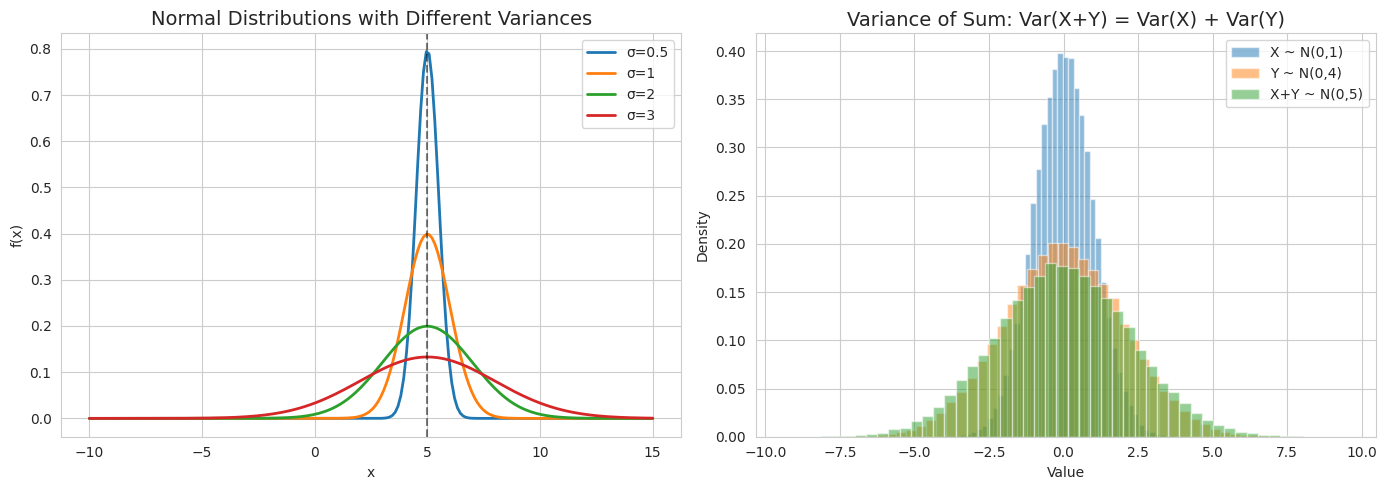

Var(X) = 1.0001, Var(Y) = 3.9953
Var(X) + Var(Y) = 4.9954
Var(X+Y) = 5.0085


In [5]:
# 分散の性質の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 分散が異なる正規分布
x = np.linspace(-10, 15, 200)
for sigma in [0.5, 1, 2, 3]:
    y = stats.norm.pdf(x, 5, sigma)
    axes[0].plot(x, y, label=f'σ={sigma}', linewidth=2)

axes[0].set_title('Normal Distributions with Different Variances', fontsize=14)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].axvline(x=5, color='black', linestyle='--', alpha=0.5)

# 独立変数の和の分散
X = np.random.normal(0, 1, n_samples)
Y = np.random.normal(0, 2, n_samples)
Z = X + Y

axes[1].hist(X, bins=50, alpha=0.5, density=True, label=f'X ~ N(0,1)')
axes[1].hist(Y, bins=50, alpha=0.5, density=True, label=f'Y ~ N(0,4)')
axes[1].hist(Z, bins=50, alpha=0.5, density=True, label=f'X+Y ~ N(0,5)')
axes[1].set_title('Variance of Sum: Var(X+Y) = Var(X) + Var(Y)', fontsize=14)
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Var(X) = {np.var(X):.4f}, Var(Y) = {np.var(Y):.4f}")
print(f"Var(X) + Var(Y) = {np.var(X) + np.var(Y):.4f}")
print(f"Var(X+Y) = {np.var(Z):.4f}")

## 3.3 歪度と尖度

### 歪度 (Skewness)
$$\gamma_1 = E\left[\left(\frac{X - \mu}{\sigma}\right)^3\right] = \frac{\mu_3}{\sigma^3}$$

- $\gamma_1 > 0$: 右に裾が長い（正の歪み）
- $\gamma_1 < 0$: 左に裾が長い（負の歪み）
- $\gamma_1 = 0$: 対称分布

### 尖度 (Kurtosis)
$$\gamma_2 = E\left[\left(\frac{X - \mu}{\sigma}\right)^4\right] - 3 = \frac{\mu_4}{\sigma^4} - 3$$

- $\gamma_2 > 0$: 正規分布より裾が重い（尖っている）
- $\gamma_2 < 0$: 正規分布より裾が軽い（平ら）
- $\gamma_2 = 0$: 正規分布と同じ尖り

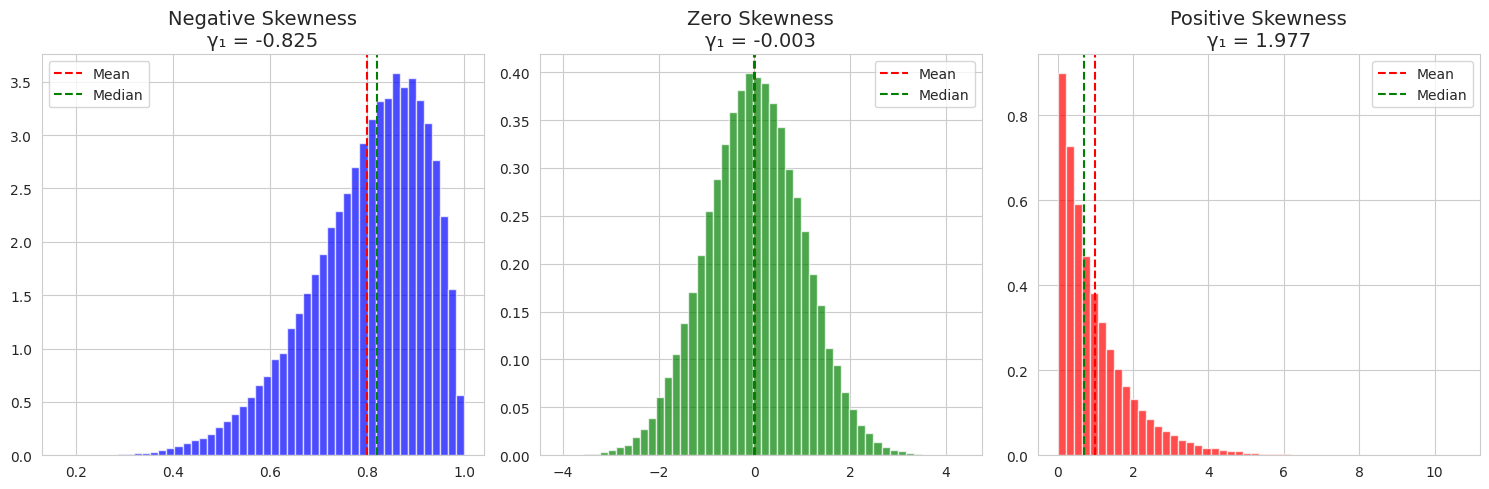

In [6]:
# 歪度の可視化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 負の歪度: ベータ分布(8, 2)
samples_neg_skew = np.random.beta(8, 2, n_samples)
axes[0].hist(samples_neg_skew, bins=50, density=True, alpha=0.7, color='blue')
skew_val = stats.skew(samples_neg_skew)
axes[0].set_title(f'Negative Skewness\nγ₁ = {skew_val:.3f}', fontsize=14)
axes[0].axvline(np.mean(samples_neg_skew), color='red', linestyle='--', label='Mean')
axes[0].axvline(np.median(samples_neg_skew), color='green', linestyle='--', label='Median')
axes[0].legend()

# 歪度 ≈ 0: 正規分布
samples_zero_skew = np.random.normal(0, 1, n_samples)
axes[1].hist(samples_zero_skew, bins=50, density=True, alpha=0.7, color='green')
skew_val = stats.skew(samples_zero_skew)
axes[1].set_title(f'Zero Skewness\nγ₁ = {skew_val:.3f}', fontsize=14)
axes[1].axvline(np.mean(samples_zero_skew), color='red', linestyle='--', label='Mean')
axes[1].axvline(np.median(samples_zero_skew), color='green', linestyle='--', label='Median')
axes[1].legend()

# 正の歪度: 指数分布
samples_pos_skew = np.random.exponential(1, n_samples)
axes[2].hist(samples_pos_skew, bins=50, density=True, alpha=0.7, color='red')
skew_val = stats.skew(samples_pos_skew)
axes[2].set_title(f'Positive Skewness\nγ₁ = {skew_val:.3f}', fontsize=14)
axes[2].axvline(np.mean(samples_pos_skew), color='red', linestyle='--', label='Mean')
axes[2].axvline(np.median(samples_pos_skew), color='green', linestyle='--', label='Median')
axes[2].legend()

plt.tight_layout()
plt.show()

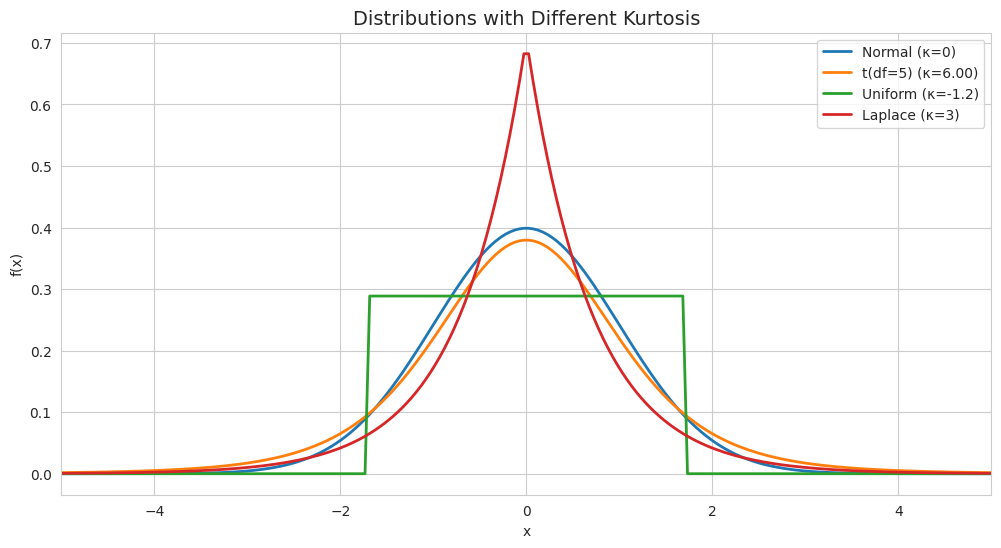

In [7]:
# 尖度の可視化
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(-5, 5, 200)

# 正規分布（尖度=0）
normal_pdf = stats.norm.pdf(x, 0, 1)
ax.plot(x, normal_pdf, label=f'Normal (κ=0)', linewidth=2)

# t分布（尖度>0、裾が重い）
t_pdf = stats.t.pdf(x, df=5)
ax.plot(x, t_pdf, label=f't(df=5) (κ={stats.t.stats(df=5, moments="k"):.2f})', linewidth=2)

# 一様分布（尖度<0）
uniform_pdf = stats.uniform.pdf(x, -np.sqrt(3), 2*np.sqrt(3))
ax.plot(x, uniform_pdf, label=f'Uniform (κ=-1.2)', linewidth=2)

# ラプラス分布（尖度>0）
laplace_pdf = stats.laplace.pdf(x, 0, 1/np.sqrt(2))
ax.plot(x, laplace_pdf, label=f'Laplace (κ=3)', linewidth=2)

ax.set_title('Distributions with Different Kurtosis', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()
ax.set_xlim(-5, 5)
plt.show()

## 3.4 共分散と相関係数

### 共分散
$$Cov(X, Y) = E[(X - \mu_X)(Y - \mu_Y)] = E[XY] - E[X]E[Y]$$

### 相関係数
$$\rho_{XY} = \frac{Cov(X, Y)}{\sigma_X \sigma_Y}$$

- $-1 \leq \rho \leq 1$
- $\rho = 1$: 完全な正の線形関係
- $\rho = -1$: 完全な負の線形関係
- $\rho = 0$: 線形関係なし（独立とは限らない）

### 重要な性質
- $Cov(X, X) = Var(X)$
- $Cov(X, Y) = Cov(Y, X)$
- $Cov(aX, bY) = ab \cdot Cov(X, Y)$
- $Var(X + Y) = Var(X) + Var(Y) + 2Cov(X, Y)$

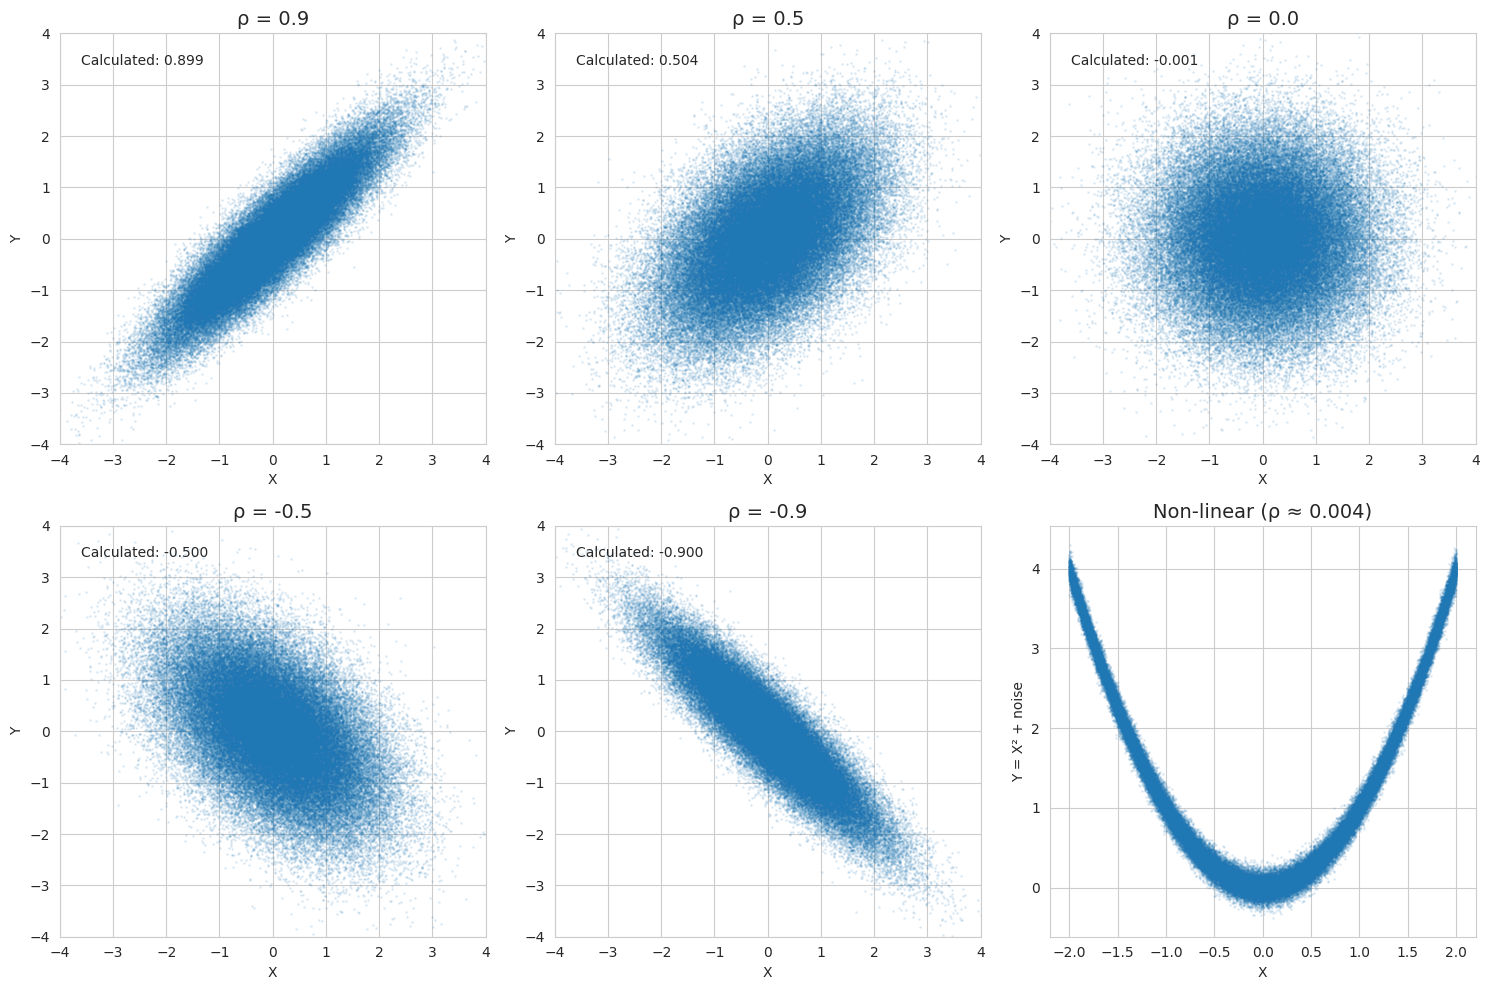

In [8]:
# 様々な相関係数の可視化
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

correlations = [0.9, 0.5, 0.0, -0.5, -0.9]

for idx, rho in enumerate(correlations):
    row, col = idx // 3, idx % 3
    
    # 相関のある2変量正規分布を生成
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    X, Y = np.random.multivariate_normal(mean, cov, n_samples).T
    
    axes[row, col].scatter(X, Y, alpha=0.1, s=1)
    axes[row, col].set_title(f'ρ = {rho}', fontsize=14)
    axes[row, col].set_xlabel('X')
    axes[row, col].set_ylabel('Y')
    axes[row, col].set_xlim(-4, 4)
    axes[row, col].set_ylim(-4, 4)
    
    # 計算された相関係数
    calc_rho = np.corrcoef(X, Y)[0, 1]
    axes[row, col].text(0.05, 0.95, f'Calculated: {calc_rho:.3f}', 
                        transform=axes[row, col].transAxes, fontsize=10,
                        verticalalignment='top')

# 非線形関係（相関=0だが独立でない）
X = np.random.uniform(-2, 2, n_samples)
Y = X**2 + np.random.normal(0, 0.1, n_samples)
axes[1, 2].scatter(X, Y, alpha=0.1, s=1)
calc_rho = np.corrcoef(X, Y)[0, 1]
axes[1, 2].set_title(f'Non-linear (ρ ≈ {calc_rho:.3f})', fontsize=14)
axes[1, 2].set_xlabel('X')
axes[1, 2].set_ylabel('Y = X² + noise')

plt.tight_layout()
plt.show()

## 3.5 条件付き期待値

### 定義
$$E[Y|X = x] = \sum_y y \cdot P(Y = y | X = x)$$ (離散)
$$E[Y|X = x] = \int_{-\infty}^{\infty} y \cdot f_{Y|X}(y|x) dy$$ (連続)

### 全期待値の法則
$$E[Y] = E[E[Y|X]]$$

### 分散の分解（条件付き分散の公式）
$$Var(Y) = E[Var(Y|X)] + Var(E[Y|X])$$

（全分散 = 平均群内分散 + 群間分散）

In [9]:
# 条件付き期待値の例：2段階確率モデル
# X ~ Poisson(λ), Y|X ~ Normal(X, 1)

n_samples = 100000
lam = 5

X = np.random.poisson(lam, n_samples)
Y = np.random.normal(X, 1)  # Y|X ~ N(X, 1)

print("条件付き期待値の例")
print("="*50)
print("モデル: X ~ Poi(5), Y|X ~ N(X, 1)")
print(f"\nE[Y|X] = X")
print(f"E[Y] = E[E[Y|X]] = E[X] = λ = 5")
print(f"\nシミュレーション結果:")
print(f"E[X] = {np.mean(X):.4f}")
print(f"E[Y] = {np.mean(Y):.4f}")

条件付き期待値の例
モデル: X ~ Poi(5), Y|X ~ N(X, 1)

E[Y|X] = X
E[Y] = E[E[Y|X]] = E[X] = λ = 5

シミュレーション結果:
E[X] = 4.9937
E[Y] = 4.9880


In [10]:
# 分散の分解の検証
# Var(Y) = E[Var(Y|X)] + Var(E[Y|X])

# この例では:
# E[Y|X] = X
# Var(Y|X) = 1

# E[Var(Y|X)] = E[1] = 1
# Var(E[Y|X]) = Var(X) = λ = 5

print("分散の分解: Var(Y) = E[Var(Y|X)] + Var(E[Y|X])")
print("="*50)

# 理論値
E_Var_Y_given_X = 1  # E[Var(Y|X)] = E[1] = 1
Var_E_Y_given_X = lam  # Var(E[Y|X]) = Var(X) = λ
total_var_theory = E_Var_Y_given_X + Var_E_Y_given_X

print(f"理論値:")
print(f"  E[Var(Y|X)] = 1")
print(f"  Var(E[Y|X]) = Var(X) = {lam}")
print(f"  Var(Y) = {total_var_theory}")

print(f"\nシミュレーション結果:")
print(f"  Var(Y) = {np.var(Y):.4f}")

分散の分解: Var(Y) = E[Var(Y|X)] + Var(E[Y|X])
理論値:
  E[Var(Y|X)] = 1
  Var(E[Y|X]) = Var(X) = 5
  Var(Y) = 6

シミュレーション結果:
  Var(Y) = 5.9404


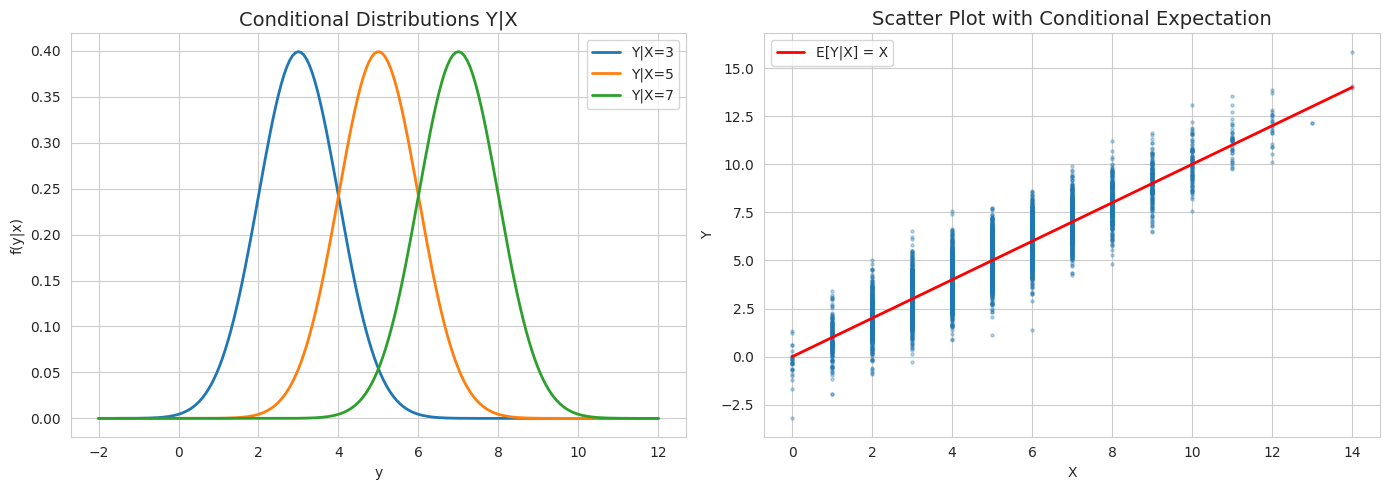

In [11]:
# 条件付き期待値の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# X = 3, 5, 7 の条件付き分布
y_range = np.linspace(-2, 12, 200)
for x_val in [3, 5, 7]:
    pdf = stats.norm.pdf(y_range, x_val, 1)
    axes[0].plot(y_range, pdf, label=f'Y|X={x_val}', linewidth=2)

axes[0].set_title('Conditional Distributions Y|X', fontsize=14)
axes[0].set_xlabel('y')
axes[0].set_ylabel('f(y|x)')
axes[0].legend()

# 散布図と条件付き期待値
# サブサンプリング
idx = np.random.choice(n_samples, 5000, replace=False)
axes[1].scatter(X[idx], Y[idx], alpha=0.3, s=5)

# E[Y|X] = X の線
x_line = np.arange(0, 15)
axes[1].plot(x_line, x_line, 'r-', linewidth=2, label='E[Y|X] = X')

axes[1].set_title('Scatter Plot with Conditional Expectation', fontsize=14)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3.6 練習問題

### 問題1
$X$ が一様分布 $U(0, 10)$ に従うとき、$E[X]$、$Var(X)$、$E[X^2]$ を求めよ。

### 問題2
$X$ と $Y$ の同時分布が以下で与えられるとき、$Cov(X, Y)$ と $\rho_{XY}$ を求めよ。

| X\Y | 0 | 1 |
|-----|---|---|
| 0 | 0.2 | 0.3 |
| 1 | 0.3 | 0.2 |

### 問題3
$N$ が平均 $\lambda$ のポアソン分布に従い、$X_1, X_2, ...$ が互いに独立で同一の分布（平均 $\mu$、分散 $\sigma^2$）に従うとき、$S = \sum_{i=1}^{N} X_i$ の期待値と分散を求めよ。

In [12]:
# 問題1の解答
print("問題1の解答: 一様分布 U(0, 10)")
print("="*50)

a, b = 0, 10

# 理論値
E_X = (a + b) / 2
Var_X = (b - a)**2 / 12
E_X2 = Var_X + E_X**2

print(f"E[X] = (a+b)/2 = {E_X}")
print(f"Var(X) = (b-a)²/12 = {Var_X:.4f}")
print(f"E[X²] = Var(X) + E[X]² = {E_X2:.4f}")

# シミュレーションで確認
X = np.random.uniform(a, b, n_samples)
print(f"\nシミュレーション:")
print(f"E[X] = {np.mean(X):.4f}")
print(f"Var(X) = {np.var(X):.4f}")
print(f"E[X²] = {np.mean(X**2):.4f}")

問題1の解答: 一様分布 U(0, 10)
E[X] = (a+b)/2 = 5.0
Var(X) = (b-a)²/12 = 8.3333
E[X²] = Var(X) + E[X]² = 33.3333

シミュレーション:
E[X] = 4.9906
Var(X) = 8.3504
E[X²] = 33.2570


In [13]:
# 問題2の解答
print("問題2の解答: 同時分布からの共分散と相関係数")
print("="*50)

# 同時確率
joint = np.array([[0.2, 0.3], [0.3, 0.2]])

# 周辺分布
P_X = np.sum(joint, axis=1)  # X=0, X=1
P_Y = np.sum(joint, axis=0)  # Y=0, Y=1

# 期待値
E_X = 0 * P_X[0] + 1 * P_X[1]
E_Y = 0 * P_Y[0] + 1 * P_Y[1]

# E[XY]
E_XY = 0*0*joint[0,0] + 0*1*joint[0,1] + 1*0*joint[1,0] + 1*1*joint[1,1]

# 共分散
Cov_XY = E_XY - E_X * E_Y

# 分散
E_X2 = 0**2 * P_X[0] + 1**2 * P_X[1]
E_Y2 = 0**2 * P_Y[0] + 1**2 * P_Y[1]
Var_X = E_X2 - E_X**2
Var_Y = E_Y2 - E_Y**2

# 相関係数
rho = Cov_XY / np.sqrt(Var_X * Var_Y)

print(f"周辺分布: P(X=0)={P_X[0]}, P(X=1)={P_X[1]}")
print(f"         P(Y=0)={P_Y[0]}, P(Y=1)={P_Y[1]}")
print(f"\nE[X] = {E_X}, E[Y] = {E_Y}")
print(f"E[XY] = {E_XY}")
print(f"\nCov(X,Y) = E[XY] - E[X]E[Y] = {Cov_XY}")
print(f"Var(X) = {Var_X}, Var(Y) = {Var_Y}")
print(f"\nρ = Cov(X,Y)/√(Var(X)Var(Y)) = {rho:.4f}")

問題2の解答: 同時分布からの共分散と相関係数
周辺分布: P(X=0)=0.5, P(X=1)=0.5
         P(Y=0)=0.5, P(Y=1)=0.5

E[X] = 0.5, E[Y] = 0.5
E[XY] = 0.2

Cov(X,Y) = E[XY] - E[X]E[Y] = -0.04999999999999999
Var(X) = 0.25, Var(Y) = 0.25

ρ = Cov(X,Y)/√(Var(X)Var(Y)) = -0.2000


In [14]:
# 問題3の解答
print("問題3の解答: ランダム和の期待値と分散")
print("="*50)

print("\nモデル: S = Σᵢ₌₁ᴺ Xᵢ")
print("N ~ Poi(λ), Xᵢ ~ iid with E[Xᵢ]=μ, Var(Xᵢ)=σ²")
print("\n条件付き期待値と分散の公式を使用:")
print("\nE[S|N] = N·μ")
print("E[S] = E[E[S|N]] = E[N·μ] = λμ")
print("\nVar(S|N) = N·σ²")
print("E[Var(S|N)] = E[N·σ²] = λσ²")
print("Var(E[S|N]) = Var(N·μ) = μ²·Var(N) = λμ²")
print("Var(S) = E[Var(S|N)] + Var(E[S|N]) = λσ² + λμ² = λ(σ² + μ²)")

# シミュレーションで確認
lam = 5
mu_x = 3
sigma_x = 2

S_samples = []
for _ in range(n_samples):
    N = np.random.poisson(lam)
    if N > 0:
        X = np.random.normal(mu_x, sigma_x, N)
        S_samples.append(np.sum(X))
    else:
        S_samples.append(0)

S_samples = np.array(S_samples)

print(f"\nシミュレーション (λ={lam}, μ={mu_x}, σ²={sigma_x**2}):")
print(f"E[S] 理論値: {lam * mu_x}, シミュレーション: {np.mean(S_samples):.4f}")
print(f"Var(S) 理論値: {lam * (sigma_x**2 + mu_x**2)}, シミュレーション: {np.var(S_samples):.4f}")

問題3の解答: ランダム和の期待値と分散

モデル: S = Σᵢ₌₁ᴺ Xᵢ
N ~ Poi(λ), Xᵢ ~ iid with E[Xᵢ]=μ, Var(Xᵢ)=σ²

条件付き期待値と分散の公式を使用:

E[S|N] = N·μ
E[S] = E[E[S|N]] = E[N·μ] = λμ

Var(S|N) = N·σ²
E[Var(S|N)] = E[N·σ²] = λσ²
Var(E[S|N]) = Var(N·μ) = μ²·Var(N) = λμ²
Var(S) = E[Var(S|N)] + Var(E[S|N]) = λσ² + λμ² = λ(σ² + μ²)



シミュレーション (λ=5, μ=3, σ²=4):
E[S] 理論値: 15, シミュレーション: 15.0128
Var(S) 理論値: 65, シミュレーション: 64.9282


## ⚠️ よくある間違いと解決策

### ❌ よくある間違い 1: 期待値と最頻値（モード）の混同

**間違った考え方:**
「期待値は最も起こりやすい値」だと考えてしまう。

**正しい理解:**
- **期待値（平均）**: 確率による重み付き平均。全ての値を考慮した「バランスポイント」
- **最頻値（mode）**: 最も頻繁に現れる値、または確率密度が最大の値

例：サイコロの期待値は3.5（決して出ない値！）

**解決策:**
離散分布で具体的に計算して違いを確認する。期待値は「長期的な平均」と理解する。

### ❌ よくある間違い 2: 相関係数と因果関係の混同

**間違った考え方:**
「相関係数が高いから、XがYの原因である」と結論づけてしまう。

**正しい理解:**
相関係数は**線形関連性の強さ**を示すだけで、因果関係は示しません。

有名な疑似相関の例:
- アイスクリームの売上 ↔ 溺死者数（夏という共通因子）

**解決策:**
因果関係の証明には、実験（ランダム化比較試験）や因果推論の手法が必要。

### ❌ よくある間違い 3: 無相関（ρ=0）と独立の混同

**間違った考え方:**
「相関係数が0だから、XとYは独立」と考えてしまう。

**正しい理解:**
- **独立** → 無相関: これは正しい
- **無相関** → 独立: これは**一般に誤り**

反例: Y=X²の場合、無相関だが独立ではない

**解決策:**
相関係数は**線形**関係のみを捉える。非線形な関係がある場合、相関係数は0でも独立ではない。

---

## 📝 理解度チェッククイズ

### 問題 1
指数分布 Exp(λ) の期待値が 1/λ であることを、定義から導出せよ。

### 問題 2  
X と Y が独立で、E[X]=2, Var(X)=3, E[Y]=5, Var(Y)=4 のとき、Z = 3X - 2Y + 7 の期待値と分散を求めよ。

### 問題 3
正規分布 N(0,1) の歪度と尖度はいくらか？これは何を意味するか？

### 問題 4
共分散が0なら2つの確率変数は独立か？反例を示せ。

---

## 📚 まとめ

### 重要ポイント

1. **期待値の線形性**: E[aX + bY] = aE[X] + bE[Y]（独立性不要）
2. **分散の性質**: Var(aX + b) = a²Var(X)、独立ならVar(X+Y) = Var(X) + Var(Y)
3. **標準化**: Z = (X-μ)/σ により、異なる尺度の変数を比較可能に
4. **歪度**: 分布の非対称性を測定（正規分布では0）
5. **尖度**: 分布の裾の重さを測定（正規分布では超過尖度0）
6. **相関と独立**: 独立→無相関、しかし無相関→独立ではない
7. **分散の分解**: Var(Y) = E[Var(Y|X)] + Var(E[Y|X])

### 重要な公式

| 特性値 | 定義 | 性質 |
|--------|------|------|
| **期待値** | $E[X] = \sum x p(x)$ | 線形性: $E[aX+bY] = aE[X]+bE[Y]$ |
| **分散** | $Var(X) = E[(X-\mu)^2]$ | $Var(aX+b) = a^2 Var(X)$ |
| **共分散** | $Cov(X,Y) = E[(X-\mu_X)(Y-\mu_Y)]$ | $Cov(X,Y) = E[XY] - E[X]E[Y]$ |
| **相関係数** | $\rho = Cov(X,Y)/(\sigma_X \sigma_Y)$ | $-1 \leq \rho \leq 1$ |
| **歪度** | $\gamma_1 = E[(X-\mu)^3]/\sigma^3$ | 対称分布では0 |
| **尖度** | $\gamma_2 = E[(X-\mu)^4]/\sigma^4 - 3$ | 正規分布では0 |

### 次のステップ

- **第4章「変数変換」**: 確率変数の関数の分布を学ぶ
- **第5-6章「離散・連続分布」**: 具体的な分布の特性値を計算
- **第8章「統計的推定の基礎」**: 標本平均・標本分散の性質を学ぶ

お疲れ様でした！分布の特性値は、これ以降の全ての章で繰り返し使う重要な概念です。

---